# 06 · Spatial Analysis

Analyses the distance between planning applications and their commenters,
broken down by stance, housing type, and topic.

**Prerequisite:** Run  first.


In [1]:
import sys
sys.path.append("../functions")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from collections import Counter

import geopandas as gpd
from shapely.geometry import Polygon

from config import (
    RESULTS_DIR, FIGURES_DIR,
    FINETUNED_MODEL_DIR, TOPIC_RUN_DATE,
    STANCE_PALETTE,
)
from data_loader import load_topics
from topic_processing import process_topics, build_topic_names

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Load data

In [2]:
comment_df = pd.read_parquet(RESULTS_DIR / "comments.parquet")
pld_df     = pd.read_parquet(RESULTS_DIR / "pld.parquet")
app_df     = pd.read_parquet(RESULTS_DIR / "applications.parquet")

raw_tp_df   = load_topics(env="dev")
tp_df       = process_topics(raw_tp_df)
tp_df       = tp_df[tp_df["add_date"] == TOPIC_RUN_DATE]

raw_topic_names = pd.read_csv(FINETUNED_MODEL_DIR / "object_topics.csv")
topic_names     = build_topic_names(raw_topic_names)
topic_name_lookup = topic_names.set_index("Topic")["topic_group"].to_dict()

# Merge comments with topics
df = pd.merge(comment_df,
              tp_df[["comment_id", "topic_number", "probability"]],
              on="comment_id", how="left")

# Merge housing type from planning data
pld_df["lpa_app_no_borough"] = pld_df["lpa_app_no"] + "_" + pld_df["borough"]
df["lpa_app_no_borough"]      = df["application_id"]  + "_" + df["council"]
df = pd.merge(df, pld_df[["lpa_app_no_borough", "housing_type",
                            "total_no_proposed_residential_units"]],
              on="lpa_app_no_borough", how="left")
print(f"{len(df):,} comments loaded")


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
30,424 comments loaded


## Build application centroid GeoDataFrame

In [3]:
app_geo = pld_df.dropna(subset=["wgs84_polygon.coordinates"]).copy()
app_geo["geometry"] = app_geo["wgs84_polygon.coordinates"].apply(
    lambda x: Polygon(x[0]) if isinstance(x, list) and x else None
)
app_gdf = gpd.GeoDataFrame(app_geo, geometry="geometry", crs="EPSG:4326")
app_gdf["centroid_lat"] = app_gdf.geometry.centroid.y
app_gdf["centroid_lon"] = app_gdf.geometry.centroid.x
print(f"Applications with centroids: {app_gdf['centroid_lat'].notna().sum():,}")


Applications with centroids: 0


/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_5177/3458534121.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  app_gdf["centroid_lat"] = app_gdf.geometry.centroid.y
/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_5177/3458534121.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  app_gdf["centroid_lon"] = app_gdf.geometry.centroid.x


## Calculate commenter–application distance (Haversine)

In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

# reset index for merging
centroid_lookup = app_gdf.set_index("lpa_app_no")
# drop duplicates in index 
centroid_lookup = centroid_lookup[~centroid_lookup.index.duplicated(keep='first')]
centroid_lookup = app_gdf[["centroid_lat", "centroid_lon"]].to_dict("index")

def calc_distance(row):
    app = centroid_lookup.get(row["application_id"], {})
    if not app or pd.isna(row["lat"]) or pd.isna(row["lon"]):
        return np.nan
    return haversine_km(row["lat"], row["lon"], app["centroid_lat"], app["centroid_lon"])

df["distance_km"] = df.apply(calc_distance, axis=1)
print(df["distance_km"].describe())


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: distance_km, dtype: float64


## Distance distributions

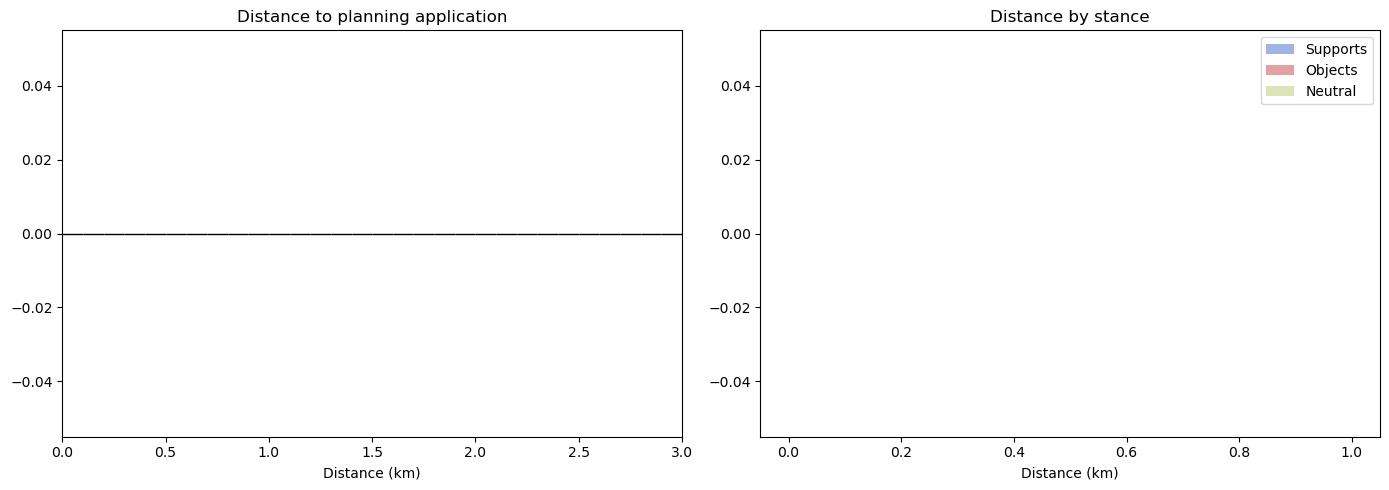

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histogram
bin_width = 0.1
max_d = 20
bins = np.arange(0, max_d + bin_width, bin_width)
axes[0].hist(df["distance_km"].dropna(), bins=bins, color="#894e9e", edgecolor="black")
axes[0].set_xlim(0, 3)
axes[0].set_xlabel("Distance (km)")
axes[0].set_title("Distance to planning application")

# By stance
for stance, color in STANCE_PALETTE.items():
    sub = df[df["stance"] == stance]["distance_km"].dropna()
    axes[1].hist(sub, bins=50, alpha=0.5, label=stance, color=color)
axes[1].set_xlabel("Distance (km)")
axes[1].set_title("Distance by stance")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "distance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## Distance by topic (boxplot)

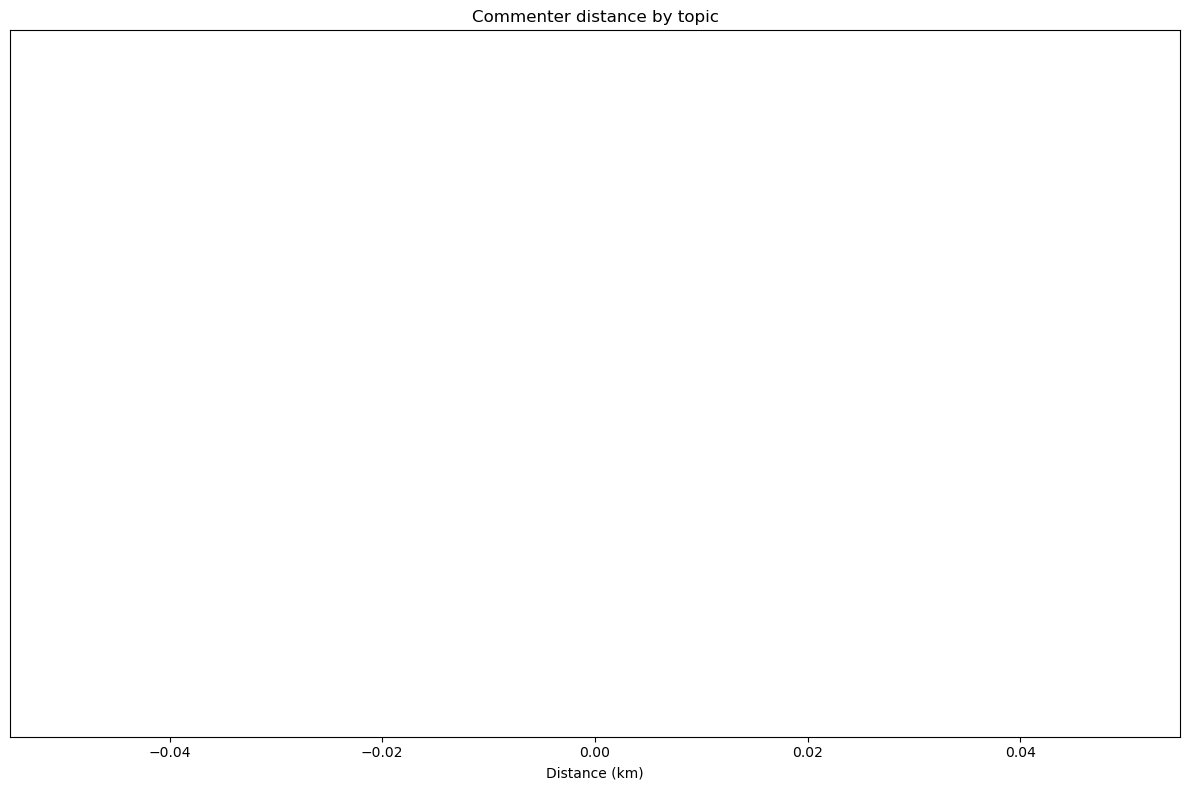

In [9]:
topic_counts = Counter(df["topic_number"].explode().dropna())
top_topics = [t for t, _ in topic_counts.most_common(15)]

data_to_plot = []
labels = []
for topic in top_topics:
    distances = df[df["topic_number"].apply(
        lambda x: topic in x if isinstance(x, list) else False
    )]["distance_km"].dropna()
    if len(distances) > 0:
        data_to_plot.append(distances)
        labels.append(topic_name_lookup.get(topic, f"Topic {topic}"))

fig, ax = plt.subplots(figsize=(12, 8))
ax.boxplot(data_to_plot, vert=False, flierprops=dict(marker="o", markersize=2, alpha=0.3))
ax.set_yticks(range(1, len(labels) + 1))
ax.set_yticklabels(labels)
ax.set_xlabel("Distance (km)")
ax.set_title("Commenter distance by topic")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distance_by_topic.png", dpi=150, bbox_inches="tight")
plt.show()


## Distance by housing type

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_5177/3344130239.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(ht_data, labels=ht_labels, vert=True,


ValueError: Dimensions of labels and X must be compatible

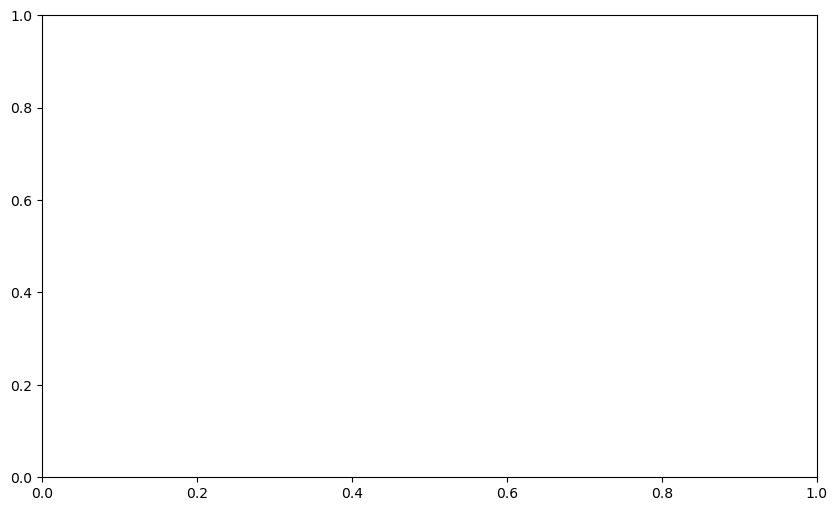

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ht_data   = []
ht_labels = []
for ht in df["housing_type"].dropna().unique():
    d = df[df["housing_type"] == ht]["distance_km"].dropna()
    if len(d):
        ht_data.append(d)
        ht_labels.append(ht)

ax.boxplot(ht_data, labels=ht_labels, vert=True,
           flierprops=dict(marker="o", markersize=2, alpha=0.3), showmeans=True)
ax.set_ylabel("Distance (km)")
ax.set_title("Commenter distance by housing type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distance_by_housing_type.png", dpi=150, bbox_inches="tight")
plt.show()
